# Entrenamiento de modelo

En este documento exploraremos diferentes modelos que demuestren su capacidad para la predicción de las 4 enfermedades:
- Anemia
- Diabetes
- Talasemia
- Trombocitopenia

y también identificar los casos de salud.

Modelos a demostrar:
- Árbol de decisiones
- Regresión lineal múltiple
- SVM
- Redes neuronales

> **Nota sobre balanceo:** El dataset original tiene Trombocitopenia con ~5% de las muestras frente al ~20% de las demás clases. Se aplica **SMOTE** al conjunto de entrenamiento para generar muestras sintéticas de la clase minoritaria. El conjunto de prueba **no se modifica** para que la evaluación refleje la realidad del dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

In [2]:
# Importamos los datos
df = pd.read_csv('data/Blood_samples_dataset_balanced_2(f).csv')
print('Shape:', df.shape)
df.head()

Shape: (2351, 25)


,Glucose,Cholesterol,Hemoglobin,Platelets,White Blood Cells,Red Blood Cells,Hematocrit,Mean Corpuscular Volume,Mean Corpuscular Hemoglobin,Mean Corpuscular Hemoglobin Concentration,...,HbA1c,LDL Cholesterol,HDL Cholesterol,ALT,AST,Heart Rate,Creatinine,Troponin,C-reactive Protein,Disease
0,0.739597,0.650198,0.713631,0.868491,0.687433,0.529895,0.290006,0.631045,0.001328,0.795829,...,0.502665,0.215560,0.512941,0.064187,0.610827,0.939485,0.095512,0.465957,0.769230,Healthy
1,0.121786,0.023058,0.944893,0.905372,0.507711,0.403033,0.164216,0.307553,0.207938,0.505562,...,0.856810,0.652465,0.106961,0.942549,0.344261,0.666368,0.659060,0.816982,0.401166,Diabetes
2,0.452539,0.116135,0.544560,0.400640,0.294538,0.382021,0.625267,0.295122,0.868369,0.026808,...,0.466795,0.387332,0.421763,0.007186,0.506918,0.431704,0.417295,0.799074,0.779208,Thalasse
3,0.136609,0.015605,0.419957,0.191487,0.081168,0.166214,0.073293,0.668719,0.125447,0.501051,...,0.016256,0.040137,0.826721,0.265415,0.594148,0.225756,0.490349,0.637061,0.354094,Anemia
4,0.176737,0.752220,0.971779,0.785286,0.443880,0.439851,0.894991,0.442159,0.257288,0.805987,...,0.429431,0.146294,0.221574,0.015280,0.567115,0.841412,0.153350,0.794008,0.094970,Thalasse


In [3]:
# Variables óptimas y variable objetivo
features = [
    'Platelets',
    'White Blood Cells',
    'Red Blood Cells',
    'Hematocrit',
    'Mean Corpuscular Volume',
    'Mean Corpuscular Hemoglobin',
    'Mean Corpuscular Hemoglobin Concentration',
    'HDL Cholesterol',
    'ALT',
    'Heart Rate'
]

X = df[features]
y = df['Disease']

# Codificación de etiquetas
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_
print('Clases:', class_names)
print('\nDistribución original:')
print(pd.Series(y).value_counts())

Clases: ['Anemia' 'Diabetes' 'Healthy' 'Thalasse' 'Thromboc']

Distribución original:
Disease
Anemia      623
Healthy     556
Diabetes    540
Thalasse    509
Thromboc    123
Name: count, dtype: int64


In [4]:
# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split estratificado — mantiene proporciones reales en test
X_train, X_test, y_train_enc, y_test_enc = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print('Train size:', X_train.shape[0])
print('Test size: ', X_test.shape[0])
print('\nDistribución en train (antes de SMOTE):')
print(pd.Series(le.inverse_transform(y_train_enc)).value_counts())

Train size: 1880
Test size:  471

Distribución en train (antes de SMOTE):
Anemia      498
Healthy     445
Diabetes    432
Thalasse    407
Thromboc     98
Name: count, dtype: int64


Train size después de SMOTE: 2490

Distribución en train (después de SMOTE):
Diabetes    498
Anemia      498
Thalasse    498
Thromboc    498
Healthy     498
Name: count, dtype: int64


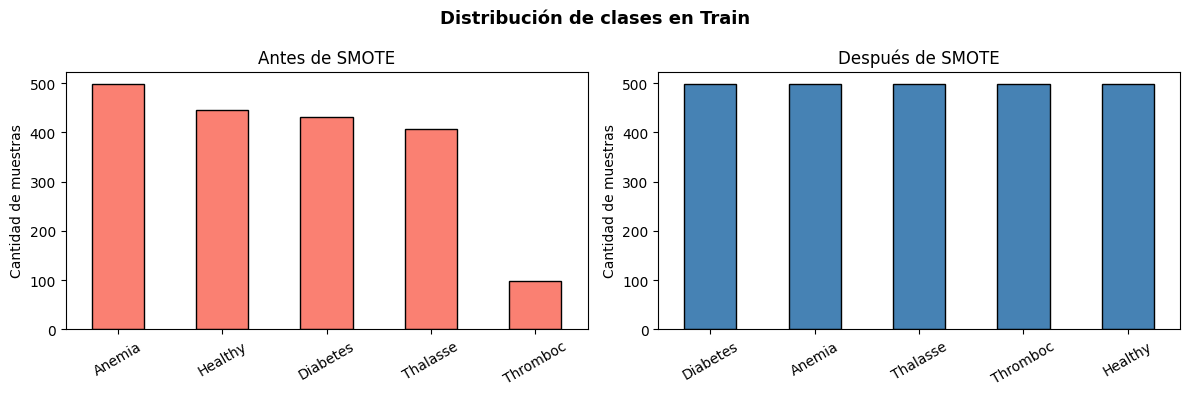

In [5]:
# Aplicamos SMOTE solo al conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train_enc)

print('Train size después de SMOTE:', X_train_bal.shape[0])
print('\nDistribución en train (después de SMOTE):')
print(pd.Series(le.inverse_transform(y_train_bal)).value_counts())

# Graficamos antes/después
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribución de clases en Train', fontsize=13, fontweight='bold')

before = pd.Series(le.inverse_transform(y_train_enc)).value_counts()
after  = pd.Series(le.inverse_transform(y_train_bal)).value_counts()

before.plot(kind='bar', ax=axes[0], color='salmon', edgecolor='black')
axes[0].set_title('Antes de SMOTE')
axes[0].set_ylabel('Cantidad de muestras')
axes[0].tick_params(axis='x', rotation=30)

after.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Después de SMOTE')
axes[1].set_ylabel('Cantidad de muestras')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('img/SMOTE_distribucion.png', dpi=120, bbox_inches='tight')
plt.show()

## Función auxiliar para graficar resultados

In [6]:
def plot_results(y_true, y_pred, model_name, class_names):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Resultados: {model_name}', fontsize=14, fontweight='bold')

    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title('Matriz de Confusión')
    axes[0].set_xlabel('Predicción')
    axes[0].set_ylabel('Real')
    axes[0].tick_params(axis='x', rotation=30)

    # Métricas por clase
    report = classification_report(y_true, y_pred, labels=class_names, output_dict=True)
    metrics_df = pd.DataFrame(report).T.loc[class_names, ['precision', 'recall', 'f1-score']]
    metrics_df.plot(kind='bar', ax=axes[1], colormap='Set2', edgecolor='black')
    axes[1].set_title('Precisión, Recall y F1-Score por Clase')
    axes[1].set_ylim(0, 1.15)
    axes[1].set_xticklabels(class_names, rotation=30, ha='right')
    axes[1].legend(loc='lower right')
    axes[1].axhline(y=0.9, color='red', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig(f'img/{model_name.replace(" ", "_")}_results.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f'\nReporte de clasificación - {model_name}:')
    print(classification_report(y_true, y_pred, labels=class_names))

## Modelo 1: Árbol de Decisión

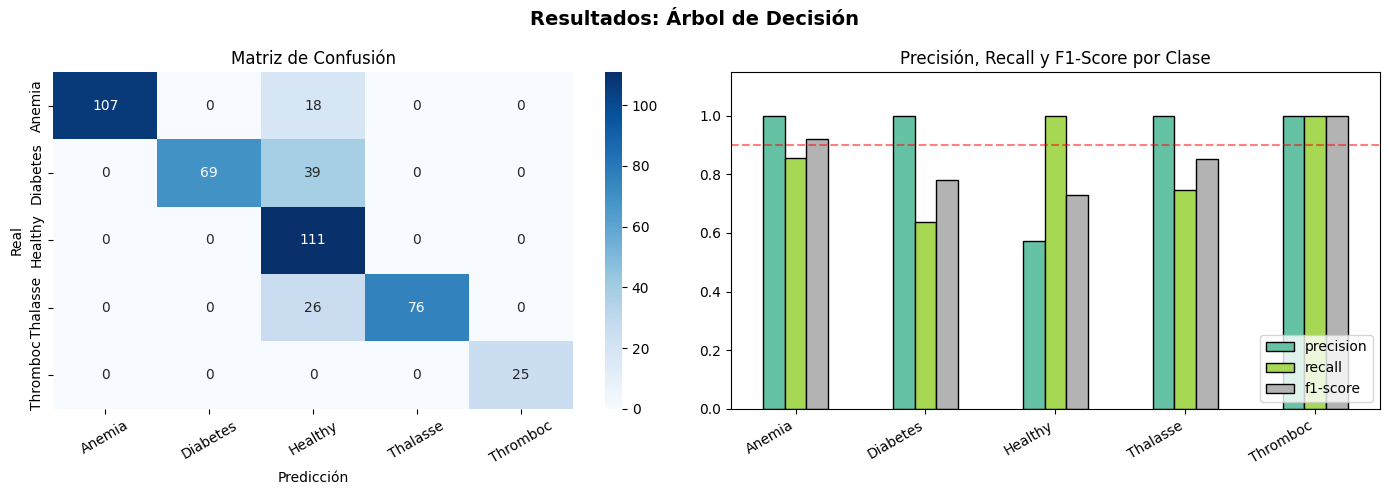


Reporte de clasificación - Árbol de Decisión:
              precision    recall  f1-score   support

      Anemia       1.00      0.86      0.92       125
    Diabetes       1.00      0.64      0.78       108
     Healthy       0.57      1.00      0.73       111
    Thalasse       1.00      0.75      0.85       102
    Thromboc       1.00      1.00      1.00        25

    accuracy                           0.82       471
   macro avg       0.91      0.85      0.86       471
weighted avg       0.90      0.82      0.83       471



In [7]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train_bal, y_train_bal)

y_pred_tree = le.inverse_transform(tree_model.predict(X_test))
y_test_str  = le.inverse_transform(y_test_enc)

plot_results(y_test_str, y_pred_tree, 'Árbol de Decisión', class_names)

## Modelo 2: Regresión Lineal Múltiple

> **Nota:** La regresión lineal es un modelo para variables continuas. Se adapta para clasificación redondeando la predicción al índice de clase más cercano. Es una aproximación didáctica; para clasificación real se prefiere SVM o árboles.

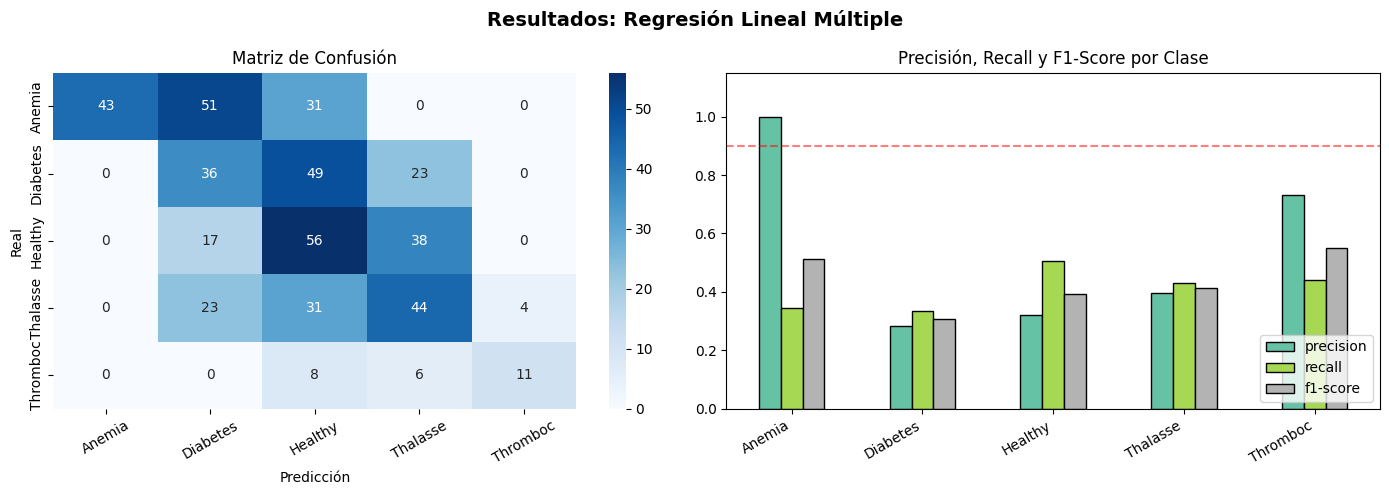


Reporte de clasificación - Regresión Lineal Múltiple:
              precision    recall  f1-score   support

      Anemia       1.00      0.34      0.51       125
    Diabetes       0.28      0.33      0.31       108
     Healthy       0.32      0.50      0.39       111
    Thalasse       0.40      0.43      0.41       102
    Thromboc       0.73      0.44      0.55        25

    accuracy                           0.40       471
   macro avg       0.55      0.41      0.43       471
weighted avg       0.53      0.40      0.42       471



In [8]:
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(X_train_bal, y_train_bal)

y_pred_lin_raw = np.clip(np.round(lin_model.predict(X_test)).astype(int), 0, len(class_names) - 1)
y_pred_lin = le.inverse_transform(y_pred_lin_raw)

plot_results(y_test_str, y_pred_lin, 'Regresión Lineal Múltiple', class_names)

## Modelo 3: SVM (Support Vector Machine)

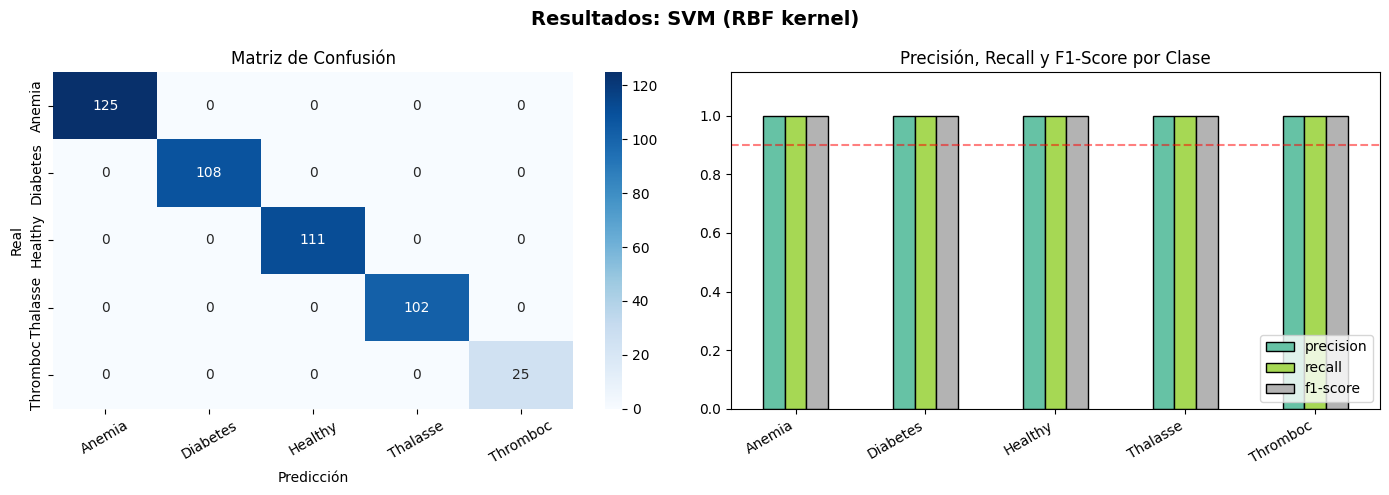


Reporte de clasificación - SVM (RBF kernel):
              precision    recall  f1-score   support

      Anemia       1.00      1.00      1.00       125
    Diabetes       1.00      1.00      1.00       108
     Healthy       1.00      1.00      1.00       111
    Thalasse       1.00      1.00      1.00       102
    Thromboc       1.00      1.00      1.00        25

    accuracy                           1.00       471
   macro avg       1.00      1.00      1.00       471
weighted avg       1.00      1.00      1.00       471



In [9]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm_model.fit(X_train_bal, y_train_bal)

y_pred_svm = le.inverse_transform(svm_model.predict(X_test))

plot_results(y_test_str, y_pred_svm, 'SVM (RBF kernel)', class_names)

## Modelo 4: Red Neuronal (MLP)

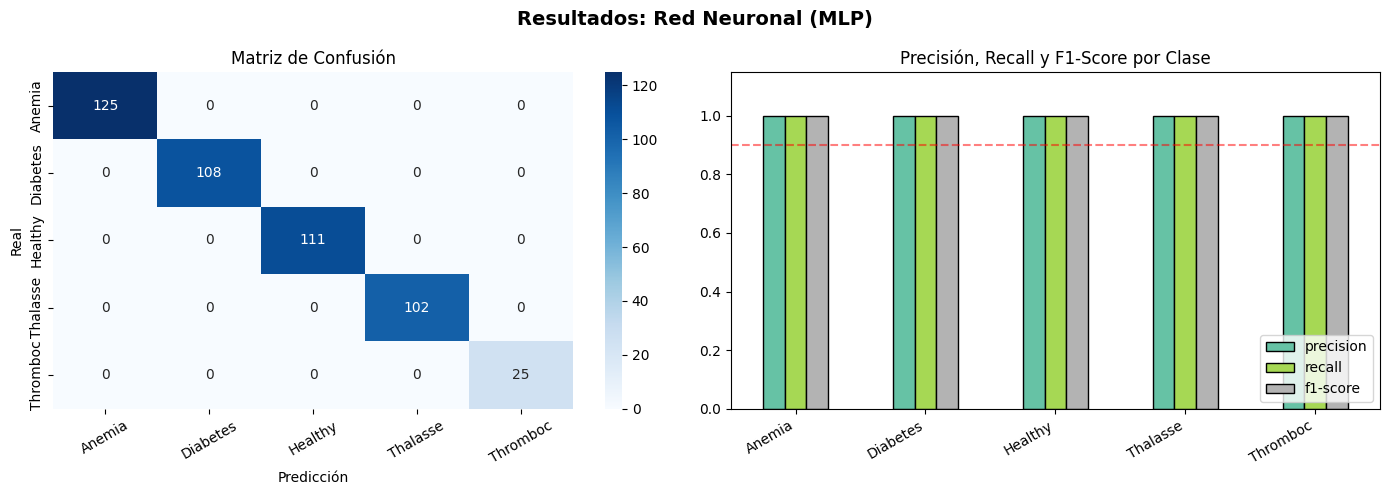


Reporte de clasificación - Red Neuronal (MLP):
              precision    recall  f1-score   support

      Anemia       1.00      1.00      1.00       125
    Diabetes       1.00      1.00      1.00       108
     Healthy       1.00      1.00      1.00       111
    Thalasse       1.00      1.00      1.00       102
    Thromboc       1.00      1.00      1.00        25

    accuracy                           1.00       471
   macro avg       1.00      1.00      1.00       471
weighted avg       1.00      1.00      1.00       471



In [10]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)
mlp_model.fit(X_train_bal, y_train_bal)

y_pred_mlp = le.inverse_transform(mlp_model.predict(X_test))

plot_results(y_test_str, y_pred_mlp, 'Red Neuronal (MLP)', class_names)


In [11]:
# Guardamos también el escalador y el label encoder para futuras predicciones
import joblib

joblib.dump(mlp_model, 'modelo_mlp.pkl')   # La red neuronal
joblib.dump(scaler,    'scaler.pkl')        # El escalador (mismo que se usó al entrenar)
joblib.dump(le,        'label_encoder.pkl') # Para decodificar números a nombre de enfermedad

['label_encoder.pkl']

## Comparación final de modelos

            Modelo  Accuracy  F1 Macro  F1 Weighted
 Árbol de Decisión  0.823779  0.856775     0.833120
  Regresión Lineal  0.403397  0.434608     0.417063
               SVM  1.000000  1.000000     1.000000
Red Neuronal (MLP)  1.000000  1.000000     1.000000


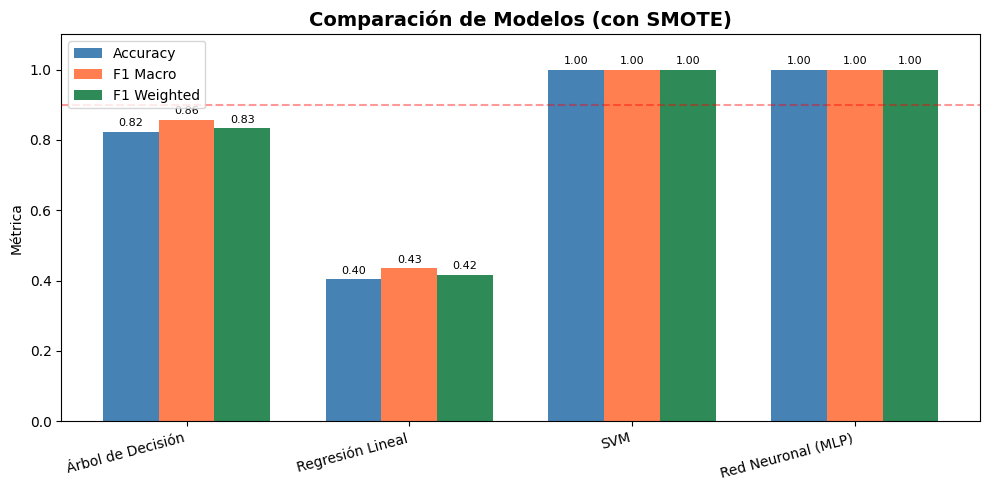

In [12]:
from sklearn.metrics import accuracy_score, f1_score

results = {
    'Árbol de Decisión':  (y_test_str, y_pred_tree),
    'Regresión Lineal':   (y_test_str, y_pred_lin),
    'SVM':                (y_test_str, y_pred_svm),
    'Red Neuronal (MLP)': (y_test_str, y_pred_mlp),
}

comparison = pd.DataFrame([
    {
        'Modelo':      name,
        'Accuracy':    accuracy_score(yt, yp),
        'F1 Macro':    f1_score(yt, yp, average='macro'),
        'F1 Weighted': f1_score(yt, yp, average='weighted')
    }
    for name, (yt, yp) in results.items()
])

print(comparison.to_string(index=False))

# Gráfica comparativa
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparison))
width = 0.25

bars1 = ax.bar(x - width, comparison['Accuracy'],     width, label='Accuracy',     color='steelblue')
bars2 = ax.bar(x,         comparison['F1 Macro'],     width, label='F1 Macro',     color='coral')
bars3 = ax.bar(x + width, comparison['F1 Weighted'],  width, label='F1 Weighted',  color='seagreen')

ax.set_title('Comparación de Modelos (con SMOTE)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison['Modelo'], rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Métrica')
ax.legend()
ax.axhline(y=0.9, color='red', linestyle='--', alpha=0.4)

for bar in [*bars1, *bars2, *bars3]:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('img/Comparacion_modelos.png', dpi=120, bbox_inches='tight')
plt.show()